# Comparison and Testing of BaselineGAT with Custom MPNN
## Loading and split dataset for BaselineGNNs

In [1]:
from atoMLtype.utils.metrics import plot_atom_distribution, plot_full_heatmap, \
    plot_category_heatmap, plot_detailed_cross_category_heatmap
from torch.utils.data import random_split
import numpy as np

# Loading MPNNdataset - Directed Bond Graphs for custom D-MPNN

In [2]:
from atoMLtype.GNN.GNNdataset import MPNNdataset

In [3]:
# Load the SDF file
sdf_path = "./data/parm_at_Frosst/zinc.sdf"
json_labels = "./data/antechamber/atomLabels_gaff2.json"

# Initialize dataset
dataset = MPNNdataset(sdf_path, json_labels, collapse=True)

[16:45:36] Explicit valence for atom # 9 N, 5, is greater than permitted
Sanitization failed for molecule at index 2131, Name: ZINC16448882. Skipping sanitization: Explicit valence for atom # 9 N, 5, is greater than permitted
[16:45:36] Explicit valence for atom # 7 N, 5, is greater than permitted
Sanitization failed for molecule at index 2721, Name: ZINC15772239. Skipping sanitization: Explicit valence for atom # 7 N, 5, is greater than permitted
[16:45:37] Explicit valence for atom # 10 N, 5, is greater than permitted
Sanitization failed for molecule at index 3249, Name: ZINC11539132. Skipping sanitization: Explicit valence for atom # 10 N, 5, is greater than permitted
[16:45:37] Explicit valence for atom # 3 N, 5, is greater than permitted
Sanitization failed for molecule at index 5699, Name: ZINC17111082. Skipping sanitization: Explicit valence for atom # 3 N, 5, is greater than permitted
Skipping molecule ZINC59391023: Missing from JSON.
Skipping molecule ZINC00335972: Missing fro

FULL DATASET:


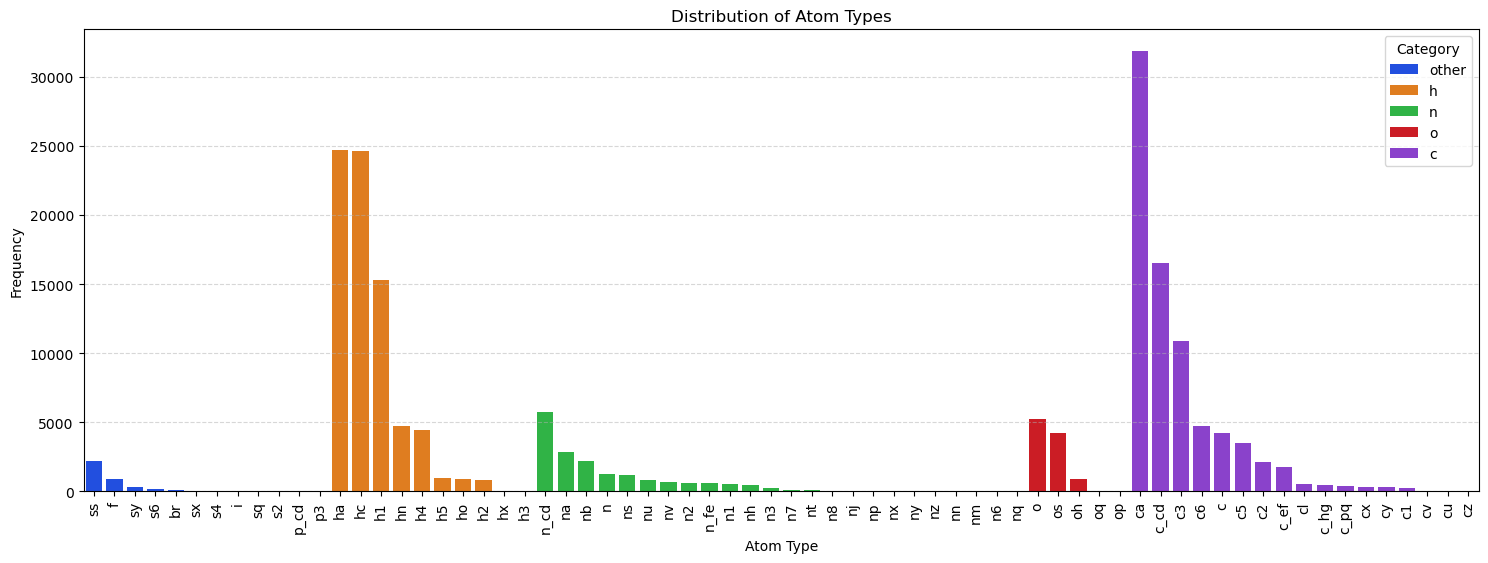

num_atom_features = 154
num_bond_features = 14
num_y_ATs = 68
Total dataset size: 6390
Train split size: 5751
Test split size: 639
First train sample: Data(x=[33, 154], edge_index=[2, 68], edge_attr=[68, 14], y=[33], y_values=[33], mol_name='ZINC00120325', atom_idx_in_mol=[33], global_atom_idx=[33])
First test sample: Data(x=[42, 154], edge_index=[2, 90], edge_attr=[90, 14], y=[42], y_values=[42], mol_name='ZINC01632331', atom_idx_in_mol=[42], global_atom_idx=[42])


In [4]:
# Initialize dataset
num_atom_feat = dataset[0].x.shape[1]
num_bond_feat = dataset[0].edge_attr.shape[1]
num_y_ATs = len(set(dataset.all_labels))

# Split Train and test dataset (95% train, 5% test)
train_size = int(0.90 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

print("FULL DATASET:")
plot_atom_distribution(np.array(dataset.all_labels))

print(f"num_atom_features = {num_atom_feat}")
print(f"num_bond_features = {num_bond_feat}")
print(f"num_y_ATs = {num_y_ATs}")

print("Total dataset size:", len(dataset))
print("Train split size:", len(train_dataset))
print("Test split size:", len(test_dataset))

# Check first few samples from each to ensure they aren't empty
print("First train sample:", train_dataset[0])
print("First test sample:", test_dataset[0])

# Test with and without Attention wieghts

Att_AtomBondMPNN - Number of parameters: 10985550
--- Fold 1/5 ---


 33%|███▎      | 10/30 [04:25<08:30, 25.54s/it]

Epoch 10: Train Loss = 0.0182, Val Loss = 0.0309


 67%|██████▋   | 20/30 [08:39<04:17, 25.71s/it]

Epoch 20: Train Loss = 0.0148, Val Loss = 0.0306


...

 33%|███▎      | 10/30 [04:19<08:22, 25.11s/it]

Epoch 10: Train Loss = 0.0054, Val Loss = 0.0112


 67%|██████▋   | 20/30 [08:25<04:07, 24.75s/it]

Epoch 20: Train Loss = 0.0050, Val Loss = 0.0113


Epoch 30: Train Loss = 0.0037, Val Loss = 0.0145


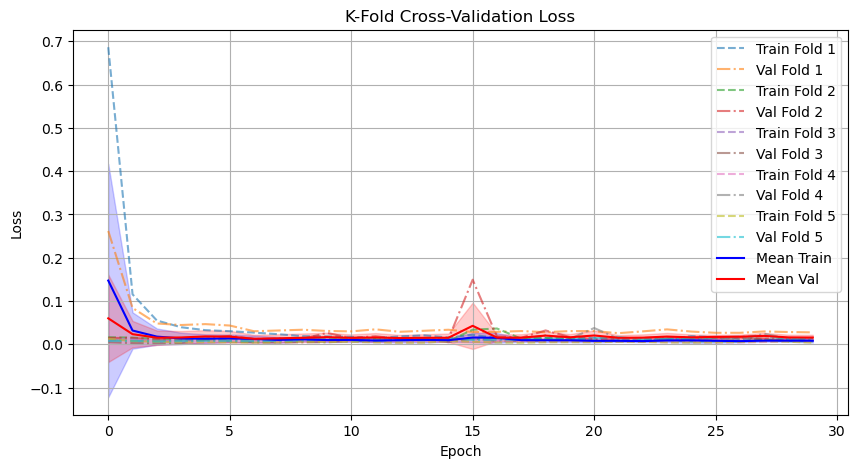

AtomBondMPNN - Number of parameters: 8323140
--- Fold 1/5 ---


 33%|███▎      | 10/30 [02:51<05:44, 17.22s/it]

Epoch 10: Train Loss = 0.0208, Val Loss = 0.0340


 67%|██████▋   | 20/30 [05:44<02:52, 17.29s/it]

Epoch 20: Train Loss = 0.0201, Val Loss = 0.0316


...

 33%|███▎      | 10/30 [02:51<05:42, 17.12s/it]

Epoch 10: Train Loss = 0.0102, Val Loss = 0.0200


 67%|██████▋   | 20/30 [05:43<02:53, 17.33s/it]

Epoch 20: Train Loss = 0.0085, Val Loss = 0.0290


Epoch 30: Train Loss = 0.0102, Val Loss = 0.0231


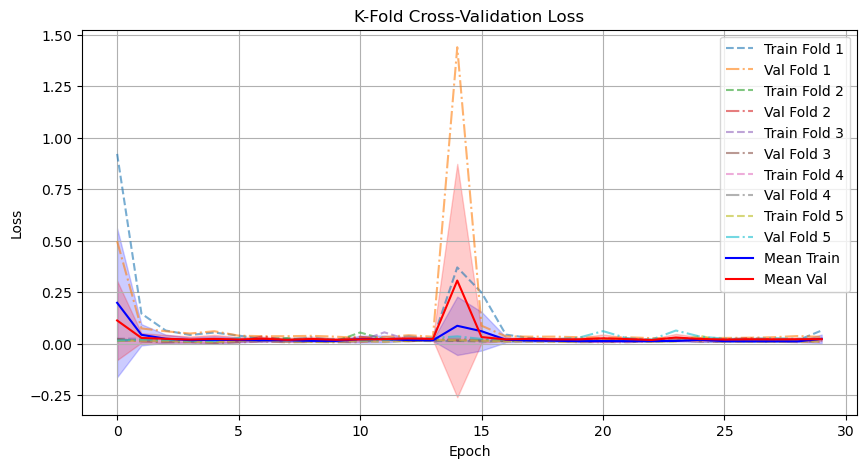

{'train_loss': [[0.9217716469422318,
   0.14610540883640175,
   0.06389423576918941,
   0.04256547736292988,
   0.05404493903331472,
   0.03924456816462504,
   0.023870490177215768,
   0.024064079983043232,
   0.023001125889857345,
   0.02084402411058606,
   0.020320222897520304,
   0.020146182754670013,
   0.018201439201113227,
   0.021897133418973445,
   0.37045905212444524,
   0.24834721273912547,
   0.04416956150933377,
   0.02682880144209274,
   0.02152813915752666,
   0.020098029792543794,
   0.016223446559270976,
   0.013971782577585882,
   0.014109031892893092,
   0.014734005164760916,
   0.01258175239392474,
   0.01046555650120894,
   0.010707358283009987,
   0.010441245734449928,
   0.015772746009514792,
   0.06409269819468129],
  [0.02174982925804263,
   0.016049235724528245,
   0.01359994547873149,
   0.012331836635177933,
   0.010948582740775236,
   0.01194012437500985,
   0.021157867842934667,
   0.02698160967088459,
   0.013651950705662984,
   0.012051704510222878,
   0.

In [31]:
from atoMLtype.GNN.MPNNmodel_custom import Att_AtomBondMPNN, AtomBondMPNN
from atoMLtype.GNN.trainer import GNNTrainer

# With Attention
model_AtomMPNN_att = Att_AtomBondMPNN(atom_input_dim=num_atom_feat, bond_input_dim=num_bond_feat, hidden_dim=512, \
                                       num_classes=num_y_ATs, num_layers=10)
trainer_AtomMPNN_att  = GNNTrainer(model_AtomMPNN_att , dataset=train_dataset, batch_size=32, learning_rate=0.001, \
                      epochs=30, k_folds=5, random_seed=21)
trainer_AtomMPNN_att.train()

# Without
model_AtomMPNN = AtomBondMPNN(atom_input_dim=num_atom_feat, bond_input_dim=num_bond_feat, hidden_dim=512, \
                                       num_classes=num_y_ATs, num_layers=10)
trainer_AtomMPNN  = GNNTrainer(model_AtomMPNN , dataset=train_dataset, batch_size=32, learning_rate=0.001, \
                      epochs=30, k_folds=5, random_seed=21)
trainer_AtomMPNN.train()

In [32]:
import atoMLtype.utils.output
import atoMLtype.engines.ModelEngine
import importlib
importlib.reload(atoMLtype.utils.output)
importlib.reload(atoMLtype.engines.ModelEngine)
from atoMLtype.engines.ModelEngine import ModelEngine

dataset_encoder = dataset.label_encoder

modelEngine_att = ModelEngine(model=model_AtomMPNN_att, 
                          dataset=test_dataset, 
                          label_encoder=dataset.label_encoder,
                          device="cpu",
                          batch_size=32)

MPNN_att_record = modelEngine_att.predict(analysis=True)

modelEngine= ModelEngine(model=model_AtomMPNN, 
                          dataset=test_dataset, 
                          label_encoder=dataset.label_encoder,
                          device="cpu",
                          batch_size=32)

MPNN_record = modelEngine.predict(analysis=True)

In [33]:
MPNN_att_record.summary()

Prediction Summary: 18503/18571 correct (99.63% accuracy)
True label distribution: Counter({'ca': 3374, 'ha': 2597, 'hc': 2385, 'c_cd': 1640, 'h1': 1540, 'c3': 1061, 'n_cd': 570, 'o': 480, 'c6': 450, 'hn': 425, 'h4': 416, 'os': 410, 'c': 395, 'c5': 345, 'na': 276, 'ss': 237, 'nb': 224, 'c2': 201, 'c_ef': 179, 'n': 131, 'f': 108, 'ns': 103, 'h2': 88, 'h5': 85, 'oh': 81, 'ho': 81, 'nu': 72, 'nv': 62, 'n_fe': 61, 'n2': 58, 'n1': 54, 'cl': 47, 'nh': 44, 'c_hg': 42, 'c_pq': 40, 'cy': 30, 'c1': 27, 'sy': 27, 'cx': 24, 'n3': 22, 'n7': 16, 's6': 14, 'br': 8, 'nt': 5, 'h3': 4, 's4': 4, 'sq': 4, 'cv': 3, 'nj': 3, 'n8': 3, 'nn': 3, 'sx': 2, 'np': 2, 'hx': 2, 'p_cd': 1, 'oq': 1, 'p3': 1, 'nz': 1, 'i': 1, 'nx': 1})
Pred label distribution: Counter({'ca': 3364, 'ha': 2590, 'hc': 2393, 'c_cd': 1645, 'h1': 1547, 'c3': 1063, 'n_cd': 567, 'o': 479, 'c6': 454, 'hn': 423, 'h4': 416, 'os': 411, 'c': 393, 'c5': 345, 'na': 275, 'ss': 237, 'nb': 224, 'c2': 203, 'c_ef': 180, 'n': 131, 'f': 108, 'ns': 102, 'h2'

In [34]:
MPNN_record.summary()

Prediction Summary: 18479/18571 correct (99.50% accuracy)
True label distribution: Counter({'ca': 3374, 'ha': 2597, 'hc': 2385, 'c_cd': 1640, 'h1': 1540, 'c3': 1061, 'n_cd': 570, 'o': 480, 'c6': 450, 'hn': 425, 'h4': 416, 'os': 410, 'c': 395, 'c5': 345, 'na': 276, 'ss': 237, 'nb': 224, 'c2': 201, 'c_ef': 179, 'n': 131, 'f': 108, 'ns': 103, 'h2': 88, 'h5': 85, 'oh': 81, 'ho': 81, 'nu': 72, 'nv': 62, 'n_fe': 61, 'n2': 58, 'n1': 54, 'cl': 47, 'nh': 44, 'c_hg': 42, 'c_pq': 40, 'cy': 30, 'c1': 27, 'sy': 27, 'cx': 24, 'n3': 22, 'n7': 16, 's6': 14, 'br': 8, 'nt': 5, 'h3': 4, 's4': 4, 'sq': 4, 'cv': 3, 'nj': 3, 'n8': 3, 'nn': 3, 'sx': 2, 'np': 2, 'hx': 2, 'p_cd': 1, 'oq': 1, 'p3': 1, 'nz': 1, 'i': 1, 'nx': 1})
Pred label distribution: Counter({'ca': 3363, 'ha': 2590, 'hc': 2392, 'c_cd': 1634, 'h1': 1545, 'c3': 1064, 'n_cd': 570, 'o': 479, 'c6': 454, 'hn': 423, 'h4': 416, 'os': 411, 'c': 393, 'c5': 345, 'na': 279, 'ss': 237, 'nb': 225, 'c2': 203, 'c_ef': 187, 'n': 131, 'f': 108, 'ns': 102, 'h2'

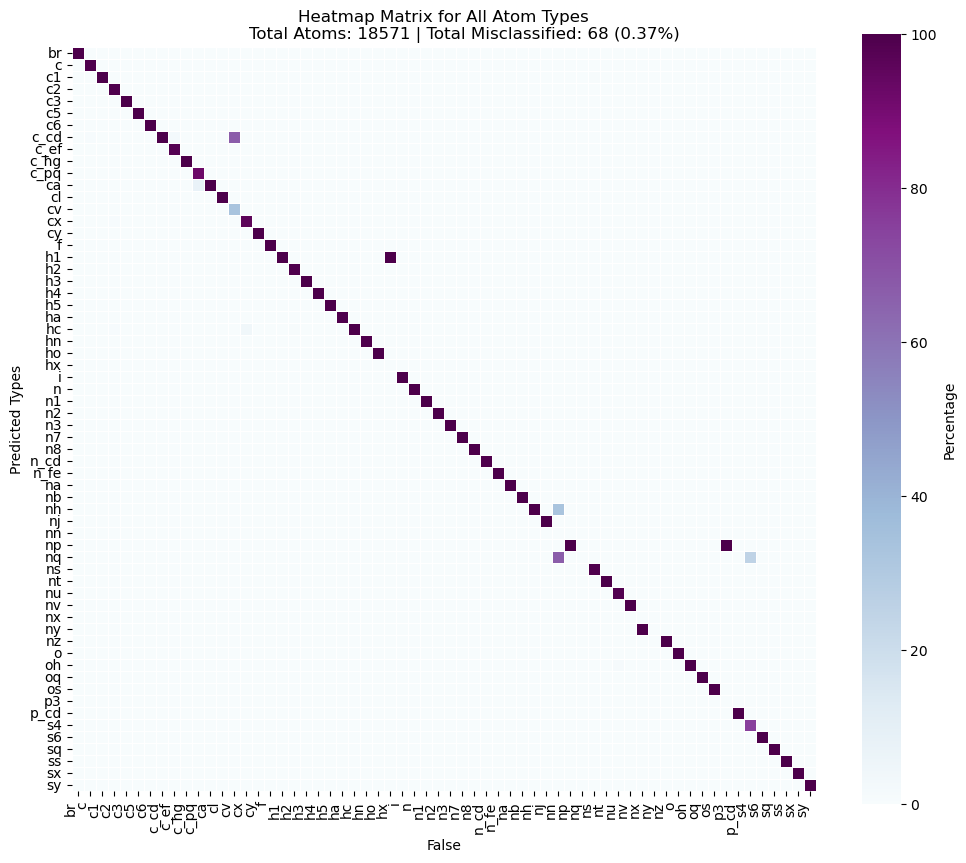

In [35]:
plot_full_heatmap(y_true=MPNN_att_record.true_labels, y_pred=MPNN_att_record.pred_labels )


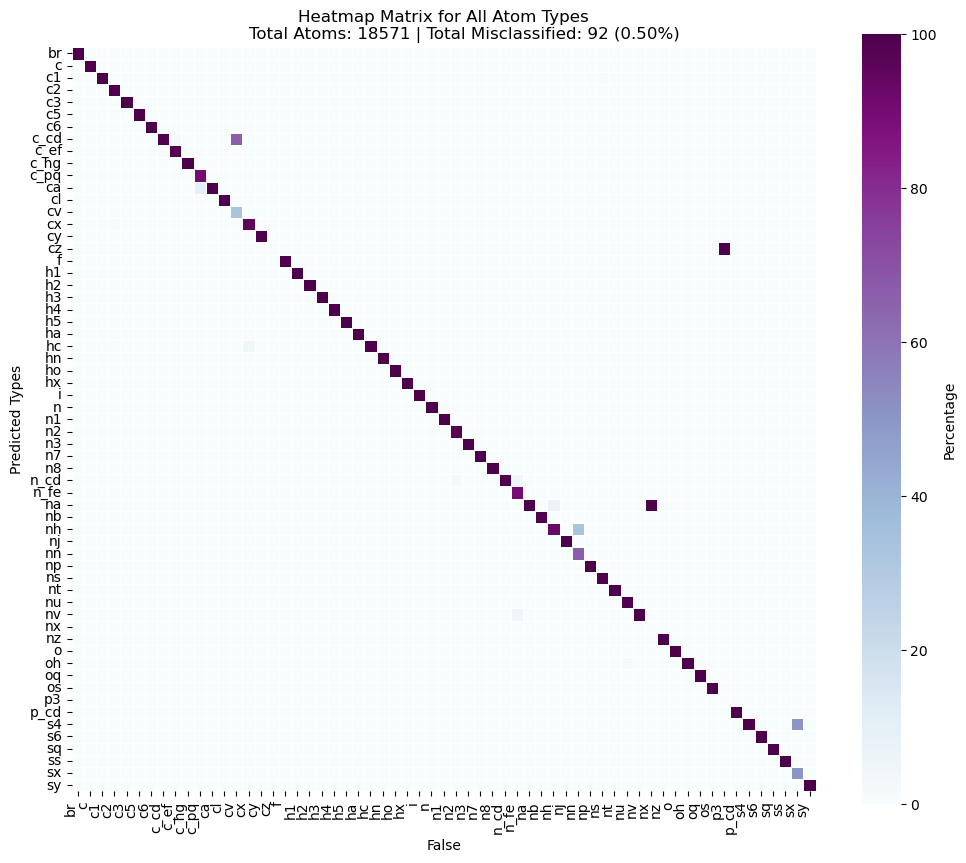

In [36]:

plot_full_heatmap(y_true=MPNN_record.true_labels, y_pred=MPNN_record.pred_labels )


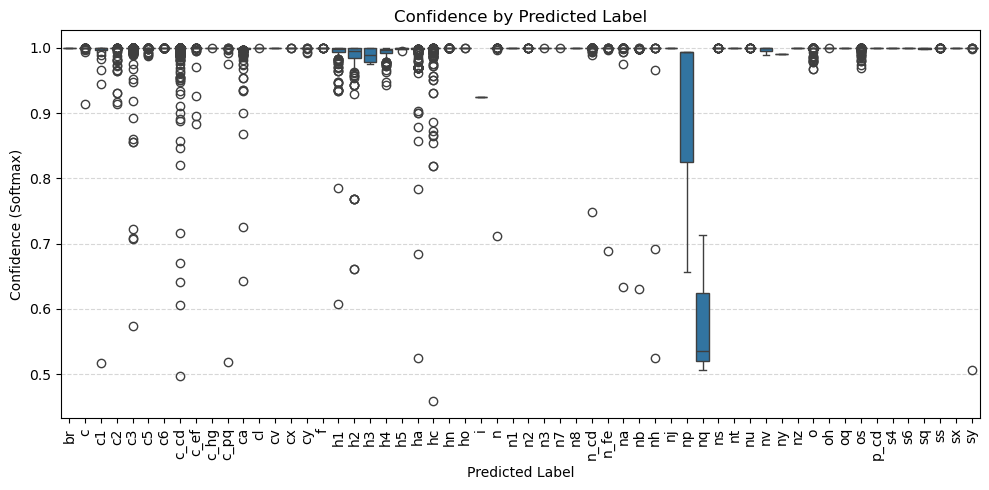

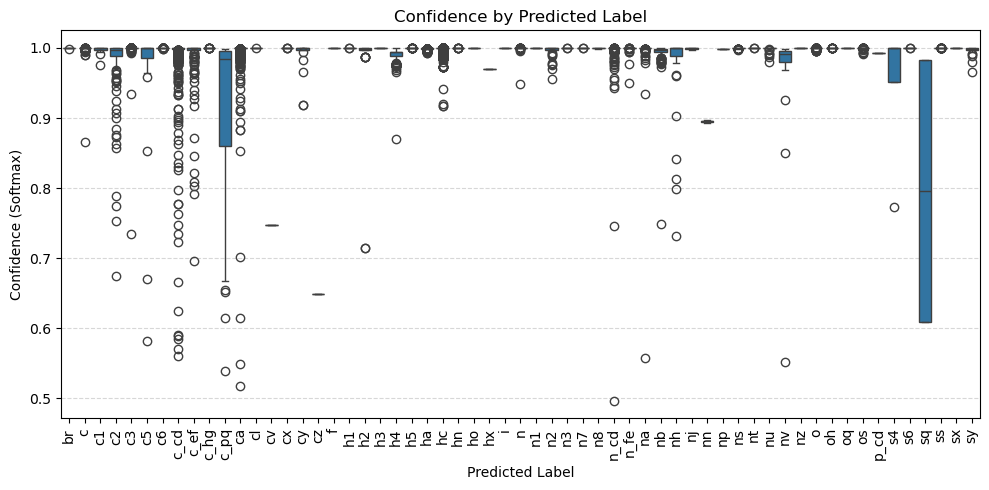

In [37]:
import atoMLtype.analysis.visualizations
importlib.reload(atoMLtype.analysis.visualizations)
from atoMLtype.analysis.visualizations import plot_confidence_by_pred_label

plot_confidence_by_pred_label(MPNN_att_record, 
                              sort_by='alphabetical', 
                              showfliers=True, 
                              figsize=(10, 5))

plot_confidence_by_pred_label(MPNN_record, 
                              sort_by='alphabetical', 
                              showfliers=True, 
                              figsize=(10, 5))

